# Second-Hand Car Price Prediction

## Project objective
Build regression models to predict **car Price** using engineered features, compare full-feature and PCA-reduced models, and interpret the model results.



In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42


## 1. Load and inspect the dataset

In [ ]:

df = pd.read_csv('second_hand_cars.csv')

print(f"Shape: {df.shape}")
df.head()


Shape: (2500, 16)


,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company Name,2500,10,Nissan,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car Name,2500,10,F-150,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant,2238,9,LE,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,2500,3,CNG,840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tyre Condition,2500,3,New,854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Make Year,2500.0,NaN,NaN,NaN,2019.5216,2.894146,2015.0,2017.0,2020.0,2022.0,2024.0
Owner Type,2500,3,Third,855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Registration Number,2500,2500,84-436-5584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,2500.0,NaN,NaN,NaN,104777.792,55544.487467,10010.0,56313.0,104209.5,152149.25,199755.0
Price,2500.0,NaN,NaN,NaN,608120.8976,231056.126713,200176.0,407791.0,612012.5,804567.0,999826.0


## 2. Missing values

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})


,missing_count,missing_pct
Accessories,482,19.28
Variant,262,10.48


### Handling missing values

- `Variant`: missing values are labelled **`Unknown`** because the variant was not recorded. This does not necessarily mean that the car has no variant.
- `Accessories`: missing values are labelled **`None`** for this project. This is an assumption: a missing value could also mean that the information was not recorded.
- Other engineered numeric values are handled later using **training-set statistics only**, so the test set does not influence preprocessing.


In [6]:
df['Variant'] = df['Variant'].fillna('Unknown')
df['Accessories'] = df['Accessories'].fillna('None')

print("Remaining missing values:")
print(df.isna().sum()[df.isna().sum() > 0])


Remaining missing values:
Series([], dtype: int64)


## 3. Remove duplicate records and the unique identifier

In [7]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows before removal: {n_dupes}")

print(f"Duplicate Registration Numbers: {df['Registration Number'].duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

# Registration Number is a unique identifier and should not be used as a predictive feature.
df = df.drop(columns=['Registration Number'])

print("Registration Number removed.")


Duplicate rows before removal: 0
Duplicate Registration Numbers: 0
Shape after dropping duplicates: (2500, 16)
Registration Number removed.


## 4. Feature engineering

In [8]:
REFERENCE_YEAR = df['Make Year'].max() + 1

# Car age
df['Car Age'] = REFERENCE_YEAR - df['Make Year']

# Required feature-engineering variable.
# IMPORTANT: this uses Price, so it MUST NOT be included in X when predicting Price.
df['Price per Mile'] = df['Price'] / df['Mileage'].replace(0, np.nan)

df[['Make Year', 'Car Age', 'Price', 'Mileage', 'Price per Mile']].head()


,Make Year,Car Age,Price,Mileage,Price per Mile
0,2018,7,759107,52798,14.377571
1,2020,5,505071,43412,11.634364
2,2022,3,635322,95219,6.672219
3,2024,1,483152,70370,6.865880
4,2018,7,712961,85852,8.304536


In [9]:
# Service Record -> whether the car has a service record
df['Has Service Record'] = (~df['Service Record'].isin(['No Service Record'])).astype(int)

def extract_service_km(text):
    if isinstance(text, str) and 'Major Service at' in text:
        return int(text.split('Major Service at')[1].strip().split(' ')[0])
    return np.nan

df['Last Service KM'] = df['Service Record'].apply(extract_service_km)



# Insurance -> binary flag
df['Has Valid Insurance'] = (df['Insurance'] != 'No Current Insurance').astype(int)

# Registration Certificate -> binary flag
df['Has Registration Certificate'] = (
    df['Registration Certificate'] == 'Available'
).astype(int)

# Accessories -> count
df['Accessories Count'] = df['Accessories'].apply(
    lambda x: 0 if x == 'None' else len([item for item in x.split(',') if item.strip()])
)

df[['Service Record', 'Has Service Record', 'Last Service KM',
    'Insurance', 'Has Valid Insurance',
    'Registration Certificate', 'Has Registration Certificate',
    'Accessories', 'Accessories Count']].head()


,Service Record,Has Service Record,Last Service KM,Insurance,Has Valid Insurance,Registration Certificate,Has Registration Certificate,Accessories,Accessories Count
0,Major Service at 50418 km,1,50418.0,No Current Insurance,0,Not Available,0,"Music System, Sunroof, Alloy Wheels",3
1,Major Service at 131313 km,1,131313.0,No Current Insurance,0,Available,1,None,0
2,No Service Record,0,NaN,No Current Insurance,0,Available,1,None,0
3,Major Service at 98115 km,1,98115.0,Valid Until [date],1,Available,1,"Music System, Alloy Wheels",2
4,Major Service at 135665 km,1,135665.0,No Current Insurance,0,Not Available,0,"GPS, Music System",2


## 5. Prepare the modelling data

`Price per Mile` is deliberately **excluded from `X`**. It is mathematically derived from `Price`, so including it would expose the target to the model and produce unreliable evaluation results.

The original raw columns used to create binary/count features are also removed from the modelling table where their engineered replacements are being used.


In [10]:
categorical_cols = [
    'Company Name', 'Car Name', 'Variant', 'Fuel Type',
    'Tyre Condition', 'Owner Type', 'Transmission Type', 'Body Color'
]

engineered_numeric = [
    'Make Year', 'Mileage', 'Car Age',
    'Last Service KM', 'Accessories Count'
]

engineered_binary = [
    'Has Service Record',
    'Has Valid Insurance',
    'Has Registration Certificate'
]

# Keep Price as y.
# Price per Mile is excluded because it is target-derived.
drop_from_model = [
    'Price',
    'Price per Mile',
    'Service Record',
    'Insurance',
    'Registration Certificate',
    'Accessories'
]

model_source = df.drop(columns=drop_from_model)

X_raw = model_source.copy()
y = df['Price'].copy()

print(f"Predictor rows: {X_raw.shape[0]}")
print(f"Predictor columns before encoding: {X_raw.shape[1]}")
print(f"Target shape: {y.shape}")


Predictor rows: 2500
Predictor columns before encoding: 16
Target shape: (2500,)


## 6. Train-test split BEFORE preprocessing

In [11]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set:", X_train_raw.shape)
print("Test set:", X_test_raw.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)


Training set: (2000, 16)
Test set: (500, 16)
Training target: (2000,)
Test target: (500,)


## 7. Encode categorical variables and handle missing values

One-hot encoding is fitted conceptually using the training data first. The test set is then aligned to exactly the same columns.

`Last Service KM` is imputed with the **training median only**. This prevents test-set information from affecting preprocessing.


In [12]:
# One-hot encode train and test separately, then align the test columns to train.
X_train = pd.get_dummies(
    X_train_raw,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

X_test = pd.get_dummies(
    X_test_raw,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Impute Last Service KM using ONLY the training median.
service_km_median = X_train['Last Service KM'].median()

X_train['Last Service KM'] = X_train['Last Service KM'].fillna(service_km_median)
X_test['Last Service KM'] = X_test['Last Service KM'].fillna(service_km_median)

print(f"Training median used for Last Service KM: {service_km_median:.2f}")
print(f"Encoded training shape: {X_train.shape}")
print(f"Encoded test shape: {X_test.shape}")
print(f"Remaining missing values in X_train: {X_train.isna().sum().sum()}")
print(f"Remaining missing values in X_test: {X_test.isna().sum().sum()}")


Training median used for Last Service KM: 103486.50
Encoded training shape: (2000, 50)
Encoded test shape: (500, 50)
Remaining missing values in X_train: 0
Remaining missing values in X_test: 0


## 8. Numeric scaling — fit on training data only

In [13]:
numeric_features = [
    'Make Year', 'Mileage', 'Car Age',
    'Last Service KM', 'Accessories Count'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY on training data.
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

# Apply the already-fitted scaler to test data.
X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("Scaler fitted on X_train only.")
X_train_scaled[numeric_features].describe().round(2)


Scaler fitted on X_train only.


,Make Year,Mileage,Car Age,Last Service KM,Accessories Count
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.55,-1.70,-1.55,-3.14,-1.44
25%,-0.86,-0.87,-0.86,0.03,-0.73
50%,0.00,-0.01,-0.00,0.03,-0.03
75%,0.86,0.83,0.86,0.03,0.68
max,1.55,1.74,1.55,2.79,1.38


## 9. Correlation analysis

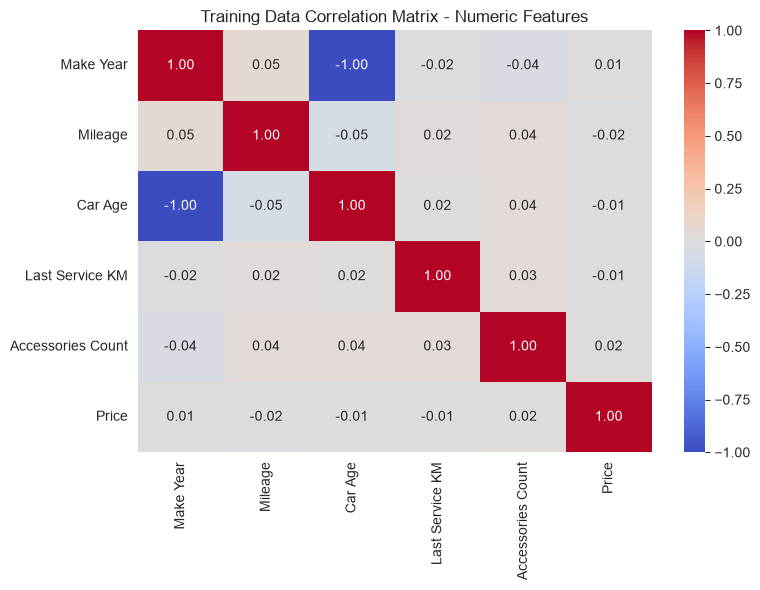

In [14]:
corr_cols = numeric_features + ['Price']
corr_matrix = pd.concat(
    [X_train_scaled[numeric_features], y_train.rename('Price')],
    axis=1
).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Training Data Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()


## 10. Remove highly correlated predictors using training data only




In [15]:
# Identify highly correlated predictor pairs from TRAINING data only.
full_corr = X_train_scaled.corr().abs()
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85
]

print(f"Highly correlated feature pairs (|corr| > 0.85): {len(high_corr_pairs)}")

to_drop = sorted(set(pair[0] for pair in high_corr_pairs))

X_train_reduced = X_train_scaled.drop(columns=to_drop)
X_test_reduced = X_test_scaled.drop(columns=to_drop)

print(f"Features before correlation reduction: {X_train_scaled.shape[1]}")
print(f"Features after correlation reduction: {X_train_reduced.shape[1]}")
print(f"Features removed: {len(to_drop)}")


Highly correlated feature pairs (|corr| > 0.85): 1
Features before correlation reduction: 50
Features after correlation reduction: 49
Features removed: 1


## 11. PCA — fit on training data only

PCA is now fitted using **`X_train_reduced` only**.

The number of components is selected using the training set's cumulative explained variance. The fitted PCA is then used to transform both training and test data.


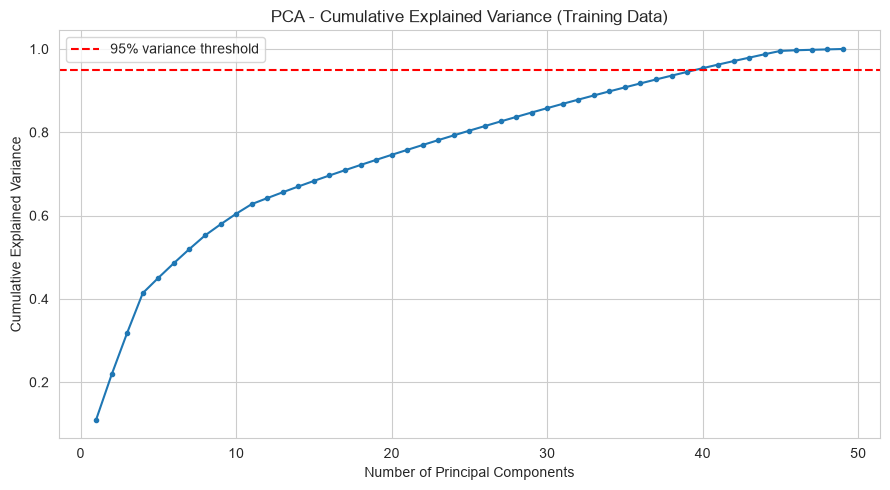

Original feature count after correlation reduction: 49
Components needed to explain 95% of training variance: 40


In [16]:
# Fit PCA on TRAINING data only.
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_reduced)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    markersize=3
)
plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% variance threshold'
)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance (Training Data)')
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Original feature count after correlation reduction: {X_train_reduced.shape[1]}")
print(f"Components needed to explain 95% of training variance: {n_components_95}")


In [17]:
# Fit the final PCA transformation using training data only.
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_reduced)
X_test_pca = pca.transform(X_test_reduced)

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=X_train_reduced.index
)

X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=X_test_reduced.index
)

print(f"Full feature shape - train: {X_train_reduced.shape}")
print(f"Full feature shape - test:  {X_test_reduced.shape}")
print(f"PCA feature shape  - train: {X_train_pca_df.shape}")
print(f"PCA feature shape  - test:  {X_test_pca_df.shape}")

X_train_pca_df.head()


Full feature shape - train: (2000, 49)
Full feature shape - test:  (500, 49)
PCA feature shape  - train: (2000, 40)
PCA feature shape  - test:  (500, 40)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
2055,-0.793758,0.801816,1.831816,-0.347790,-0.854871,-0.237973,0.402280,-0.224344,0.569116,0.066209,0.410704,0.096029,-0.126316,-0.222072,0.331672,-0.010700,0.251782,-0.245299,-0.553377,0.139250,-0.133314,-0.553236,0.169538,-0.206509,0.131248,0.233667,-0.255987,0.248866,0.249268,-0.336881,0.118054,0.275820,0.029129,-0.088874,-0.484540,0.542775,-0.092728,-0.101382,0.244651,0.038791
1961,0.164475,0.390166,-0.473468,-2.200865,0.496104,0.141479,0.045394,-0.222324,-0.418463,-0.110297,-0.814348,0.953414,0.201909,0.380522,-0.055743,-0.331247,-0.033066,-0.066629,-0.032413,0.216233,-0.277513,-0.106435,0.270035,-0.254376,0.121437,0.237220,-0.674771,-0.183558,-0.598101,0.058543,-0.323849,0.791996,0.475194,0.370014,0.184487,-0.290058,0.416520,0.138042,0.377875,0.351135
1864,1.061008,1.674594,1.686919,-0.771935,0.111982,0.166341,0.614829,0.564619,0.592641,-0.025590,0.381155,-0.064591,0.128410,-0.260798,0.060225,-0.098336,-0.189752,-0.093654,0.443800,-0.377293,-0.165758,-0.107439,-0.348338,0.300875,-0.745121,-0.104863,0.331301,0.210610,-0.023714,0.197745,0.187633,0.222000,-0.371054,0.161055,-0.250801,-0.241807,-0.057185,-0.355156,0.466172,-0.023810
2326,1.273461,1.152970,-0.962850,-0.167922,0.351036,-0.004348,-0.724344,-0.948008,-0.753561,0.187381,0.172686,-0.146036,-0.646747,0.324402,0.130097,-0.224295,-0.209017,-0.516119,-0.078030,0.235733,0.088423,0.026585,0.012490,0.090447,0.042473,-0.243196,0.390000,0.424457,0.357934,0.185076,-0.191579,-0.255720,0.098767,0.340620,0.726176,-0.306181,0.267086,-0.148892,0.247007,0.612839
461,-1.821050,0.079963,1.154827,-0.927778,0.029297,1.078045,0.382668,-0.803223,-0.918143,0.077973,0.039677,0.086551,-0.230195,-0.273460,-0.374199,-0.540853,0.397464,0.210612,-0.507972,-0.324851,0.791597,0.357986,0.147262,0.099175,0.341512,-0.289081,0.339245,0.402792,0.167062,0.687619,-0.574807,0.035123,-0.294526,-0.017923,-0.025973,0.137826,-0.047073,-0.315161,-0.079490,-0.095545


## 12. Model comparison

The same four regression models are evaluated on:
1. the corrected full feature set, and
2. the PCA-reduced feature set.

The train/test split is identical in both experiments.


In [18]:
def evaluate(model, X_train_data, X_test_data, y_train_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    predictions = model.predict(X_test_data)

    return {
        'MAE': mean_absolute_error(y_test_data, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test_data, predictions)),
        'R2': r2_score(y_test_data, predictions)
    }

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

results = []

for name, model in models.items():
    full_scores = evaluate(
        model,
        X_train_reduced,
        X_test_reduced,
        y_train,
        y_test
    )

    pca_scores = evaluate(
        model,
        X_train_pca_df,
        X_test_pca_df,
        y_train,
        y_test
    )

    results.append({
        'Model': name,
        'Feature Set': 'Full',
        **full_scores
    })

    results.append({
        'Model': name,
        'Feature Set': 'PCA',
        **pca_scores
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    ['Feature Set', 'R2'],
    ascending=[True, False]
).reset_index(drop=True)


,Model,Feature Set,MAE,RMSE,R2
0,Ridge Regression,Full,206322.304876,237676.046243,-0.019354
1,Linear Regression,Full,206316.098342,237700.980159,-0.019568
2,Random Forest,Full,213013.365640,243761.581934,-0.072222
3,Gradient Boosting,Full,211976.464418,244010.568723,-0.074413
4,Ridge Regression,PCA,205885.553914,236368.307762,-0.008167
5,Linear Regression,PCA,205888.871000,236376.635418,-0.008238
6,Random Forest,PCA,207204.042390,238239.307426,-0.024191
7,Gradient Boosting,PCA,207034.883000,240091.831751,-0.040181


## 13. Interpret the corrected results

In [19]:
# Compare R2 directly between Full and PCA for each model.
r2_comparison = results_df.pivot(
    index='Model',
    columns='Feature Set',
    values='R2'
)

r2_comparison['R2 Difference (PCA - Full)'] = (
    r2_comparison['PCA'] - r2_comparison['Full']
)

r2_comparison.sort_values('R2 Difference (PCA - Full)', ascending=False)


Feature Set,Full,PCA,R2 Difference (PCA - Full)
Model,,,
Random Forest,-0.072222,-0.024191,0.048031
Gradient Boosting,-0.074413,-0.040181,0.034232
Linear Regression,-0.019568,-0.008238,0.011329
Ridge Regression,-0.019354,-0.008167,0.011186


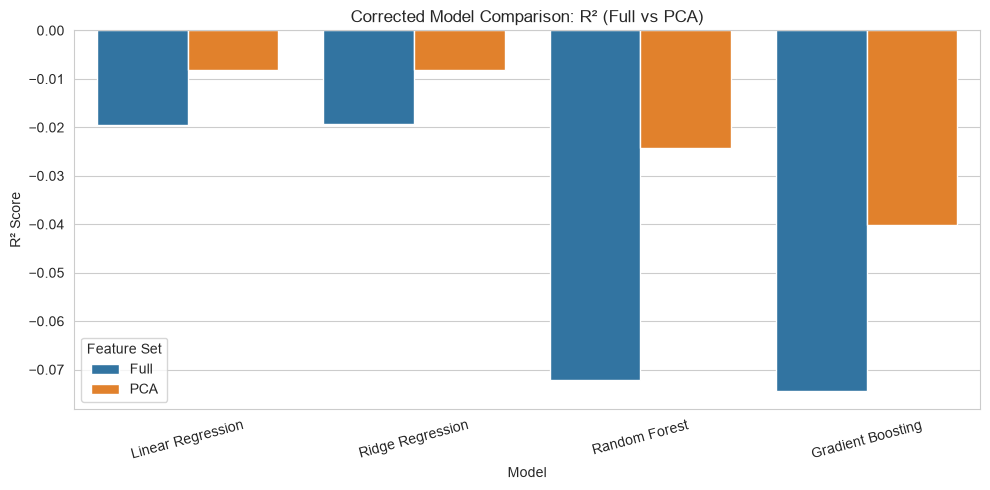

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x='Model',
    y='R2',
    hue='Feature Set'
)
plt.title('Corrected Model Comparison: R² (Full vs PCA)')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### How to interpret the PCA result

A 95% explained-variance threshold describes variance retained in the **feature space**, not 95% of the information needed to predict `Price`.

Therefore, PCA should be judged using the downstream regression metrics:
- If PCA has a similar R² and error to the full feature set, dimensionality reduction may provide a useful simplification.
- If PCA has substantially lower R² or higher errors, then the removed dimensions contained predictive information that was useful for the target.
- The corrected results above should be used instead of the original leakage-affected results.


## 14. Random Forest feature importance

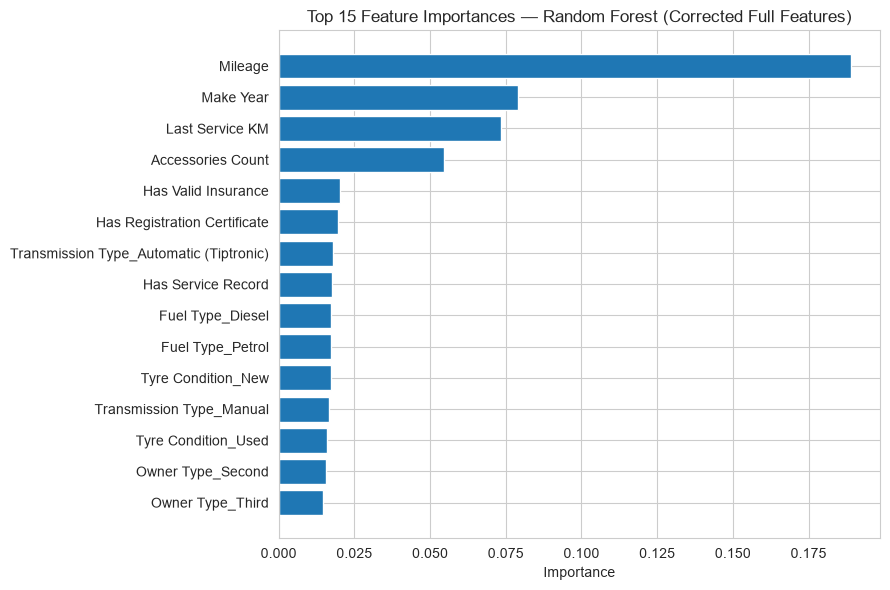

Mileage                                    0.189118
Make Year                                  0.078899
Last Service KM                            0.073502
Accessories Count                          0.054497
Has Valid Insurance                        0.020304
Has Registration Certificate               0.019567
Transmission Type_Automatic (Tiptronic)    0.017844
Has Service Record                         0.017549
Fuel Type_Diesel                           0.017444
Fuel Type_Petrol                           0.017367
Tyre Condition_New                         0.017207
Transmission Type_Manual                   0.016506
Tyre Condition_Used                        0.015937
Owner Type_Second                          0.015475
Owner Type_Third                           0.014498
dtype: float64

In [21]:
# Fit Random Forest on the corrected full feature set.
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_reduced, y_train)

importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train_reduced.columns
)

top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(top_importances.index[::-1], top_importances.values[::-1])
plt.title('Top 15 Feature Importances — Random Forest (Corrected Full Features)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_importances


### Feature-importance interpretation

The table and plot above identify which predictors the corrected Random Forest relied on most when reducing prediction error.

Interpret the highest-ranked features in the context of the dataset rather than treating feature importance as causation. A high importance means the feature was useful to the model's predictions; it does not prove that changing that feature would directly cause a change in car price.


## 15. Final conclusion


The PCA conclusion should also be based on the actual difference between Full and PCA model performance. Retaining 95% feature variance alone does not guarantee that predictive performance will be retained.
